# ML model analyse

This notebook is used to load the model and analyse the results

In [2]:
import pandas as pd
import torch 
import numpy as np
import torch.nn as nn
from torchsummary import summary
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from datetime import datetime
import neptune
import model as mf

from torchvision.io import read_image
from torchvision.transforms.functional import to_tensor


DATA_PATH = "dataset/" #Do not change folder structure that was created by Kasper
# dataset/
#   DRR_images/
#       [n].png
#   excel/
#       *.xlsx 


In [ ]:
#read_image("buffer/IMAGE_X210_Y0.png").squeeze().shape
#read_image("dataset/DRR_images/C0001_X0_Y0.png").squeeze().shape

NameError: name 'read_image' is not defined

In [41]:
labels = pd.read_excel(DATA_PATH+"excel/all_DRR_scores.xlsx")
labels['fullpath'] = DATA_PATH+"DRR_images/"+labels['DRR filename']+".png"
labels['score_classified'] = pd.qcut(labels['score'], 5).factorize()[0]

#labels.iloc[0]['fullpath']
labels

,DRR filename,aneurysm score,neck score,score,fullpath,score_classified
0,C0001_X0_Y0,12.272727,1.783784,14.056511,dataset/DRR_images/C0001_X0_Y0.png,0
1,C0001_X10_Y0,7.358974,1.584906,8.943880,dataset/DRR_images/C0001_X10_Y0.png,1
2,C0001_X20_Y0,5.538462,1.921569,7.460030,dataset/DRR_images/C0001_X20_Y0.png,1
3,C0001_X30_Y0,5.309091,2.074074,7.383165,dataset/DRR_images/C0001_X30_Y0.png,1
4,C0001_X40_Y0,4.949153,1.689189,6.638342,dataset/DRR_images/C0001_X40_Y0.png,2
...,...,...,...,...,...,...
6835,C0074_X310_Y180,2.008721,2.130435,4.139156,dataset/DRR_images/C0074_X310_Y180.png,3
6836,C0074_X320_Y180,1.817175,1.709091,3.526265,dataset/DRR_images/C0074_X320_Y180.png,4
6837,C0074_X330_Y180,1.527578,2.289474,3.817052,dataset/DRR_images/C0074_X330_Y180.png,4
6838,C0074_X340_Y180,3.066038,2.050000,5.116038,dataset/DRR_images/C0074_X340_Y180.png,3


In [42]:
import torch.utils.data.dataloader


device = torch.device("cuda")
model = mf.Block()
data_loader_2 = mf.TestImageDataset("buffer/")
data_loader_1 = mf.CustomImageDataset(labels)
data_loader = torch.utils.data.DataLoader(data_loader_1, batch_size=64, shuffle=True)

Feature batch shape: torch.Size([64, 1, 256, 256])
Feature batch type: torch.FloatTensor
Labels batch shape: torch.Size([64])


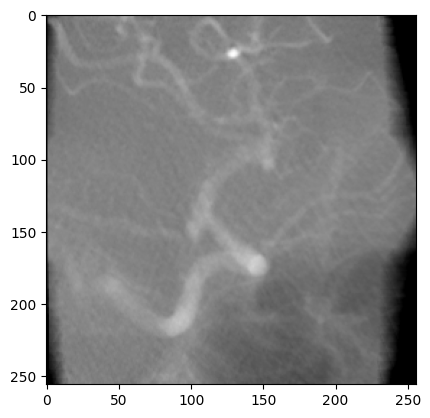

Label: 4


In [48]:
train, labels = next(iter(data_loader))
print(f"Feature batch shape: {train.size()}")
print(f"Feature batch type: {train.type()}")
print(f"Labels batch shape: {labels.size()}")
img = train[0].squeeze()
label = labels[0]
plt.imshow(img, cmap="gray")
plt.show()
#print(f"Name: {name[0]}")
print(f"Label: {labels[0]}")

In [49]:
model.load_state_dict(torch.load("mymodel_classified.pth"))
model.to(device)
outputs = model(train.to(device))

In [50]:
labels

tensor([4, 0, 3, 0, 1, 4, 1, 2, 2, 3, 2, 2, 2, 1, 3, 0, 2, 4, 1, 2, 1, 4, 1, 1,
        3, 3, 2, 1, 3, 1, 1, 0, 2, 4, 1, 4, 1, 4, 1, 1, 2, 2, 2, 0, 2, 2, 1, 1,
        2, 4, 1, 1, 2, 3, 1, 1, 2, 1, 2, 0, 3, 1, 1, 0])

In [51]:
outputs

tensor([[-6.6393e+00,  2.0354e+00, -1.3648e+00, -9.6280e+00,  1.0576e+01],
        [ 2.8422e-01,  3.0354e-01,  3.0446e-01, -5.2838e-01, -6.8381e-01],
        [-7.9333e+00, -1.1167e+01, -1.3239e+01,  1.1198e+01, -3.2453e+00],
        [ 2.8422e-01,  3.0354e-01,  3.0446e-01, -5.2838e-01, -6.8381e-01],
        [-1.5597e+00, -1.5667e+01, -1.3588e+00,  1.0922e+01,  6.2698e+00],
        [-9.0154e+00, -1.1152e+00, -9.9183e+00, -2.3336e+00,  1.3874e+01],
        [ 2.8422e-01,  3.0354e-01,  3.0446e-01, -5.2838e-01, -6.8381e-01],
        [ 4.3776e-01, -2.4906e+01, -1.0149e+01, -2.6102e+00, -1.0539e+01],
        [-2.5329e+00, -5.5638e+00,  1.1893e+01, -3.7454e+00,  2.6492e+00],
        [-8.6338e+00, -1.3237e+01, -4.5285e+00,  1.6390e+01,  2.2197e+00],
        [-1.4356e+01, -1.3072e+01,  1.0592e+01, -7.1417e+00, -9.9596e+00],
        [ 2.8422e-01,  3.0354e-01,  3.0446e-01, -5.2838e-01, -6.8381e-01],
        [-2.1284e+01, -1.9203e+01,  1.4237e+01, -9.2310e+00, -1.4881e+01],
        [-4.0553e+00,  9.

In [52]:
_, predicted = torch.max(outputs,1)
total = len(labels)
correct = 0

for label, prediction in zip(labels, predicted.detach().cpu()):
    if label == prediction:
        #print(label, prediction)
        correct = correct + 1

print(f'Accuracy: {(correct/total):5f}')

Accuracy: 0.640625


In [53]:
predicted

tensor([4, 2, 3, 2, 3, 4, 2, 0, 2, 3, 2, 2, 2, 1, 3, 2, 2, 4, 2, 2, 1, 2, 2, 2,
        3, 2, 2, 0, 3, 2, 1, 0, 0, 4, 1, 4, 1, 2, 1, 1, 2, 1, 4, 0, 2, 4, 1, 3,
        2, 4, 0, 2, 2, 3, 2, 1, 2, 1, 2, 0, 3, 1, 1, 2], device='cuda:0')